# ST-GCN for Skeleton Action Recognition

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
# Cell 1: Imports
import os
import math
import pickle
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


In [15]:
# Cell 2: Seed and device
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("torch version:", torch.__version__)


device: cuda
torch version: 2.10.0+cu128


In [16]:
# Cell 3: Path to your pkl file and quick inspection

PKL_PATH = "/content/drive/MyDrive/ntu60_hrnet.pkl"

with open(PKL_PATH, "rb") as f:
    data = pickle.load(f)

print(type(data))
print(data.keys())
print("split keys:", data["split"].keys())
print("num annotations:", len(data["annotations"]))

sample = data["annotations"][0]
print("sample keys:", sample.keys())
print("sample frame_dir:", sample["frame_dir"])
print("sample label:", sample["label"])
print("sample keypoint shape:", sample["keypoint"].shape)

if "keypoint_score" in sample:
    print("sample keypoint_score shape:", sample["keypoint_score"].shape)
else:
    print("sample has no keypoint_score")


<class 'dict'>
dict_keys(['split', 'annotations'])
split keys: dict_keys(['xsub_train', 'xsub_val', 'xview_train', 'xview_val'])
num annotations: 56578
sample keys: dict_keys(['frame_dir', 'label', 'img_shape', 'original_shape', 'total_frames', 'keypoint', 'keypoint_score'])
sample frame_dir: S001C001P001R001A001
sample label: 0
sample keypoint shape: (1, 103, 17, 2)
sample keypoint_score shape: (1, 103, 17)


In [17]:
# Cell 4: Build index from split names to annotation indices
annotations = data["annotations"]
split = data["split"]

frame_dir_to_idx = {}
for i, ann in enumerate(annotations):
    frame_dir_to_idx[ann["frame_dir"]] = i

def build_indices(name_list):
    indices = []
    missing = []
    for name in name_list:
        if name in frame_dir_to_idx:
            indices.append(frame_dir_to_idx[name])
        else:
            missing.append(name)
    return indices, missing


#  default xsub_train / xsub_val
#  change xview here if want to
train_indices, missing_train = build_indices(split["xsub_train"])
val_indices, missing_val = build_indices(split["xsub_val"])

print("train size:", len(train_indices), "| missing:", len(missing_train))
print("val size  :", len(val_indices), "| missing:", len(missing_val))


train size: 40091 | missing: 0
val size  : 16487 | missing: 0


In [18]:
# Cell 5: Hyperparameters
NUM_CLASSES = 60
MAX_FRAMES = 100
NUM_PERSON = 2
USE_SCORE = True

BATCH_SIZE = 64
NUM_EPOCHS = 20
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 2

# ST-GCN architecture
CHANNELS = [64, 64, 64, 128, 128, 128, 256, 256, 256]
STRIDES =  [1,  1,  1,  2,   1,   1,   2,   1,   1]
DROPOUT = 0.5

print("CHANNELS:", CHANNELS)
print("STRIDES :", STRIDES)


CHANNELS: [64, 64, 64, 128, 128, 128, 256, 256, 256]
STRIDES : [1, 1, 1, 2, 1, 1, 2, 1, 1]


In [19]:
# Cell 6: Utility functions for preprocessing
def resize_time_axis(seq, target_len=100):
    '''
    seq: numpy array shape (C, T, V)
    output: (C, target_len, V)
    '''
    C, T, V = seq.shape
    if T == target_len:
        return seq.astype(np.float32)

    old_idx = np.linspace(0, T - 1, num=T)
    new_idx = np.linspace(0, T - 1, num=target_len)

    out = np.zeros((C, target_len, V), dtype=np.float32)
    for c in range(C):
        for v in range(V):
            out[c, :, v] = np.interp(new_idx, old_idx, seq[c, :, v])
    return out

def select_top_persons(keypoint, keypoint_score=None, max_person=2):
    '''
    keypoint: (M, T, V, 2)
    keypoint_score: (M, T, V) or None
    return selected keypoint/keypoint_score with first dimension <= max_person
    '''
    M = keypoint.shape[0]
    if M <= max_person:
        if keypoint_score is None:
            return keypoint, None
        return keypoint, keypoint_score

    if keypoint_score is not None:
        person_score = keypoint_score.sum(axis=(1, 2))
    else:
        # fallback nếu không có score
        person_score = np.abs(keypoint).sum(axis=(1, 2, 3))

    top_idx = np.argsort(-person_score)[:max_person]
    top_idx = np.sort(top_idx)

    if keypoint_score is None:
        return keypoint[top_idx], None
    return keypoint[top_idx], keypoint_score[top_idx]

def build_stgcn_input(keypoint, keypoint_score=None, max_frames=100, num_person=2, use_score=True):
    '''
    keypoint: (M, T, V, 2)
    keypoint_score: (M, T, V) or None
    output: (C, T, V, M)
    '''
    keypoint = np.asarray(keypoint, dtype=np.float32)
    if keypoint_score is not None:
        keypoint_score = np.asarray(keypoint_score, dtype=np.float32)

    keypoint, keypoint_score = select_top_persons(
        keypoint, keypoint_score, max_person=num_person
    )

    M, T, V, _ = keypoint.shape
    C = 3 if (use_score and keypoint_score is not None) else 2

    out = np.zeros((C, max_frames, V, num_person), dtype=np.float32)

    for m in range(min(M, num_person)):
        xy = keypoint[m].transpose(2, 0, 1)   # (2, T, V)
        xy = resize_time_axis(xy, target_len=max_frames)
        out[0:2, :, :, m] = xy

        if C == 3:
            sc = keypoint_score[m][None, :, :]  # (1, T, V)
            sc = resize_time_axis(sc, target_len=max_frames)
            out[2:3, :, :, m] = sc

    return out

def compute_mean_std(dataset, max_batches=None):
    '''
    dataset trả về x shape (C, T, V, M)
    dùng để normalize input toàn cục
    '''
    channel_sum = None
    channel_sq_sum = None
    count = 0

    num_samples = len(dataset) if max_batches is None else min(len(dataset), max_batches * 32)

    for i in range(num_samples):
        x, _ = dataset[i]  # tensor
        x = x.numpy()
        c = x.shape[0]
        x = x.reshape(c, -1)

        if channel_sum is None:
            channel_sum = x.sum(axis=1)
            channel_sq_sum = (x ** 2).sum(axis=1)
        else:
            channel_sum += x.sum(axis=1)
            channel_sq_sum += (x ** 2).sum(axis=1)

        count += x.shape[1]

    mean = channel_sum / count
    std = np.sqrt(channel_sq_sum / count - mean ** 2)
    std = np.maximum(std, 1e-6)
    return mean.astype(np.float32), std.astype(np.float32)


In [20]:
# Cell 7: Dataset
class NTUSkeletonSTGCNDataset(Dataset):
    def __init__(self, annotations, indices, max_frames=100, num_person=2, use_score=True, mean=None, std=None):
        self.annotations = annotations
        self.indices = indices
        self.max_frames = max_frames
        self.num_person = num_person
        self.use_score = use_score
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        ann = self.annotations[self.indices[idx]]

        keypoint = ann["keypoint"]                         # expected: (M, T, V, 2)
        keypoint_score = ann.get("keypoint_score", None)  # expected: (M, T, V)
        label = int(ann["label"])

        x = build_stgcn_input(
            keypoint=keypoint,
            keypoint_score=keypoint_score,
            max_frames=self.max_frames,
            num_person=self.num_person,
            use_score=self.use_score,
        )

        if self.mean is not None and self.std is not None:
            x = (x - self.mean[:, None, None, None]) / self.std[:, None, None, None]

        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(label, dtype=torch.long)
        return x, y

# tạo bản dataset thô trước để tính mean/std
train_dataset_raw = NTUSkeletonSTGCNDataset(
    annotations, train_indices,
    max_frames=MAX_FRAMES,
    num_person=NUM_PERSON,
    use_score=USE_SCORE,
    mean=None,
    std=None,
)

mean, std = compute_mean_std(train_dataset_raw, max_batches=None)
print("mean:", mean)
print("std :", std)

train_dataset = NTUSkeletonSTGCNDataset(
    annotations, train_indices,
    max_frames=MAX_FRAMES,
    num_person=NUM_PERSON,
    use_score=USE_SCORE,
    mean=mean,
    std=std,
)

val_dataset = NTUSkeletonSTGCNDataset(
    annotations, val_indices,
    max_frames=MAX_FRAMES,
    num_person=NUM_PERSON,
    use_score=USE_SCORE,
    mean=mean,
    std=std,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

x0, y0 = train_dataset[0]
print("one sample shape:", x0.shape)  # (C, T, V, M)
print("one label:", y0.item())


mean: [5.784558e+02 3.311240e+02 5.072363e-01]
std : [4.9857095e+02 3.0631238e+02 4.3259791e-01]
one sample shape: torch.Size([3, 100, 17, 2])
one label: 0


In [ ]:
# Cell 8: Graph definition
class Graph:
    def __init__(self, layout="coco17", strategy="spatial"):
        self.layout = layout
        self.strategy = strategy
        self.num_node, self.self_link, self.inward = self._get_edge(layout)
        self.outward = [(j, i) for (i, j) in self.inward]
        self.A = self._get_adjacency(strategy)

    def _get_edge(self, layout):
        if layout != "coco17":
            raise ValueError(f"Unsupported layout: {layout}")

        num_node = 17
        self_link = [(i, i) for i in range(num_node)]

        #   0 nose
        #   1 left_eye, 2 right_eye
        #   3 left_ear, 4 right_ear
        #   5 left_shoulder, 6 right_shoulder
        #   7 left_elbow, 8 right_elbow
        #   9 left_wrist, 10 right_wrist
        #   11 left_hip, 12 right_hip
        #   13 left_knee, 14 right_knee
        #   15 left_ankle, 16 right_ankle
        inward = [
            (1, 0), (2, 0),
            (3, 1), (4, 2),
            (5, 0), (6, 0),
            (7, 5), (8, 6),
            (9, 7), (10, 8),
            (11, 5), (12, 6),
            (13, 11), (14, 12),
            (15, 13), (16, 14),
            (12, 11), (6, 5)
        ]
        return num_node, self_link, inward

    def _edge_to_mat(self, edges, num_node):
        A = np.zeros((num_node, num_node), dtype=np.float32)
        for i, j in edges:
            A[j, i] = 1.0
        return A

    def _normalize_digraph(self, A):
        Dl = np.sum(A, axis=0)
        Dn = np.zeros((A.shape[0], A.shape[1]), dtype=np.float32)
        for i in range(A.shape[1]):
            if Dl[i] > 0:
                Dn[i, i] = Dl[i] ** (-1)
        AD = np.dot(A, Dn)
        return AD

    def _get_adjacency(self, strategy):
        if strategy != "spatial":
            raise ValueError(f"Unsupported strategy: {strategy}")

        I = self._edge_to_mat(self.self_link, self.num_node)
        In = self._normalize_digraph(self._edge_to_mat(self.inward, self.num_node))
        Out = self._normalize_digraph(self._edge_to_mat(self.outward, self.num_node))

        A = np.stack([I, In, Out], axis=0).astype(np.float32)
        return A

graph = Graph(layout="coco17", strategy="spatial")
A = torch.tensor(graph.A, dtype=torch.float32)
print("A shape:", A.shape)   # expected: (3, 17, 17)


A shape: torch.Size([3, 17, 17])


In [22]:
# Cell 9: ST-GCN modules and model
class SpatialGraphConv(nn.Module):
    def __init__(self, in_channels, out_channels, A_size):
        super().__init__()
        self.A_size = A_size
        self.conv = nn.Conv2d(in_channels, out_channels * A_size, kernel_size=1)

    def forward(self, x, A):
        # x: (N, C, T, V)
        x = self.conv(x)  # (N, out_channels * K, T, V)
        N, KC, T, V = x.shape
        K = self.A_size
        x = x.view(N, K, KC // K, T, V)
        x = torch.einsum("nkctv,kvw->nctw", x, A)
        return x.contiguous()

class STGCNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, A_size, stride=1, residual=True, dropout=0.5):
        super().__init__()
        self.gcn = SpatialGraphConv(in_channels, out_channels, A_size)

        self.tcn = nn.Sequential(
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=(9, 1),
                stride=(stride, 1),
                padding=(4, 0),
            ),
            nn.BatchNorm2d(out_channels),
            nn.Dropout(dropout),
        )

        if not residual:
            self.residual = lambda x: 0
        elif (in_channels == out_channels) and (stride == 1):
            self.residual = nn.Identity()
        else:
            self.residual = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=(stride, 1)),
                nn.BatchNorm2d(out_channels),
            )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x, A):
        res = self.residual(x)
        x = self.gcn(x, A)
        x = self.tcn(x)
        x = x + res
        x = self.relu(x)
        return x

class STGCN(nn.Module):
    def __init__(self, in_channels, num_classes, A, num_person=2, channels=None, strides=None, dropout=0.5,
                 edge_importance_weighting=True):
        super().__init__()
        if channels is None:
            channels = [64, 64, 64, 128, 128, 128, 256, 256, 256]
        if strides is None:
            strides = [1, 1, 1, 2, 1, 1, 2, 1, 1]

        assert len(channels) == len(strides)

        A_tensor = torch.tensor(A, dtype=torch.float32)
        self.register_buffer("A", A_tensor)

        self.num_person = num_person
        self.in_channels = in_channels
        self.num_node = A_tensor.shape[1]
        self.data_bn = nn.BatchNorm1d(num_person * in_channels * self.num_node)

        blocks = []
        prev_c = in_channels
        for i, (c, s) in enumerate(zip(channels, strides)):
            residual = False if i == 0 else True
            blocks.append(STGCNBlock(prev_c, c, A_size=A_tensor.shape[0], stride=s, residual=residual, dropout=dropout))
            prev_c = c
        self.blocks = nn.ModuleList(blocks)
        if edge_importance_weighting:
            self.edge_importance = nn.ParameterList([
                nn.Parameter(torch.ones_like(self.A)) for _ in self.blocks
            ])
        else:
            self.edge_importance = [1.0] * len(self.blocks)
        self.fc = nn.Linear(prev_c, num_classes)

    def forward(self, x):
        # x: (N, C, T, V, M)
        N, C, T, V, M = x.shape
        assert C == self.in_channels
        assert V == self.num_node
        assert M == self.num_person

        # BatchNorm on input
        x = x.permute(0, 4, 3, 1, 2).contiguous()   # (N, M, V, C, T)
        x = x.view(N, M * V * C, T)                 # (N, M*V*C, T)
        x = self.data_bn(x)
        x = x.view(N, M, V, C, T)
        x = x.permute(0, 1, 3, 4, 2).contiguous()   # (N, M, C, T, V)
        x = x.view(N * M, C, T, V)                  # (N*M, C, T, V)

        for block, importance in zip(self.blocks, self.edge_importance):
            x = block(x, self.A * importance)

        # Global average pool over T and V
        x = x.mean(dim=-1).mean(dim=-1)             # (N*M, C_last)
        x = x.view(N, M, -1).mean(dim=1)            # average over persons
        x = self.fc(x)                              # (N, num_classes)
        return x

IN_CHANNELS = 3 if USE_SCORE else 2

model = STGCN(
    in_channels=IN_CHANNELS,
    num_classes=NUM_CLASSES,
    A=graph.A,
    num_person=NUM_PERSON,
    channels=CHANNELS,
    strides=STRIDES,
    dropout=DROPOUT,
).to(device)

print(model)

# quick shape check
x_dummy = torch.randn(2, IN_CHANNELS, MAX_FRAMES, 17, NUM_PERSON).to(device)
with torch.no_grad():
    y_dummy = model(x_dummy)
print("dummy output shape:", y_dummy.shape)


STGCN(
  (data_bn): BatchNorm1d(102, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (blocks): ModuleList(
    (0): STGCNBlock(
      (gcn): SpatialGraphConv(
        (conv): Conv2d(3, 192, kernel_size=(1, 1), stride=(1, 1))
      )
      (tcn): Sequential(
        (0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (1): ReLU(inplace=True)
        (2): Conv2d(64, 64, kernel_size=(9, 1), stride=(1, 1), padding=(4, 0))
        (3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (4): Dropout(p=0.5, inplace=False)
      )
      (relu): ReLU(inplace=True)
    )
    (1-2): 2 x STGCNBlock(
      (gcn): SpatialGraphConv(
        (conv): Conv2d(64, 192, kernel_size=(1, 1), stride=(1, 1))
      )
      (tcn): Sequential(
        (0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (1): ReLU(inplace=True)
        (2): Conv2d(64, 64, kernel_size=(9, 1), stride

In [23]:
# Cell 10: Training and evaluation functions
def compute_accuracy(logits, targets):
    preds = torch.argmax(logits, dim=1)
    return (preds == targets).float().mean().item()

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    total_count = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        batch_size = x.size(0)
        total_loss += loss.item() * batch_size
        total_acc += compute_accuracy(logits, y) * batch_size
        total_count += batch_size

    return total_loss / total_count, total_acc / total_count

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    total_count = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        batch_size = x.size(0)
        total_loss += loss.item() * batch_size
        total_acc += compute_accuracy(logits, y) * batch_size
        total_count += batch_size

    return total_loss / total_count, total_acc / total_count


In [24]:
# Cell 11: Train
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

best_val_acc = 0.0
SAVE_DIR = "/content/drive/MyDrive/skeleton_project_outputs/stgcn"
os.makedirs(SAVE_DIR, exist_ok=True)
best_model_path = os.path.join(SAVE_DIR, "best_stgcn.pth")

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    scheduler.step()
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)

print("best val acc:", best_val_acc)
print("best model saved to:", best_model_path)

history_path = os.path.join(SAVE_DIR, "training_history_stgcn.csv")
try:
    import pandas as pd
    pd.DataFrame(history).to_csv(history_path, index=False)
except ImportError:
    import csv
    with open(history_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["train_loss", "train_acc", "val_loss", "val_acc"])
        writer.writerows(zip(
            history["train_loss"],
            history["train_acc"],
            history["val_loss"],
            history["val_acc"],
        ))
print("history saved to:", history_path)


Epoch 01/20 | train_loss=2.9318 train_acc=0.1798 | val_loss=2.0940 val_acc=0.3472
Epoch 02/20 | train_loss=1.6052 train_acc=0.4807 | val_loss=1.5672 val_acc=0.5084
Epoch 03/20 | train_loss=1.1806 train_acc=0.6082 | val_loss=1.3842 val_acc=0.5520
Epoch 04/20 | train_loss=0.9580 train_acc=0.6758 | val_loss=1.4208 val_acc=0.5867
Epoch 05/20 | train_loss=0.8214 train_acc=0.7208 | val_loss=1.0710 val_acc=0.6711
Epoch 06/20 | train_loss=0.7213 train_acc=0.7525 | val_loss=1.2714 val_acc=0.6401
Epoch 07/20 | train_loss=0.6571 train_acc=0.7750 | val_loss=0.9527 val_acc=0.7059
Epoch 08/20 | train_loss=0.6118 train_acc=0.7925 | val_loss=0.9690 val_acc=0.7075
Epoch 09/20 | train_loss=0.5661 train_acc=0.8054 | val_loss=1.1871 val_acc=0.6599
Epoch 10/20 | train_loss=0.5398 train_acc=0.8152 | val_loss=0.9893 val_acc=0.7112
Epoch 11/20 | train_loss=0.4144 train_acc=0.8554 | val_loss=0.6585 val_acc=0.7868
Epoch 12/20 | train_loss=0.3909 train_acc=0.8651 | val_loss=0.6309 val_acc=0.7997
Epoch 13/20 | tr

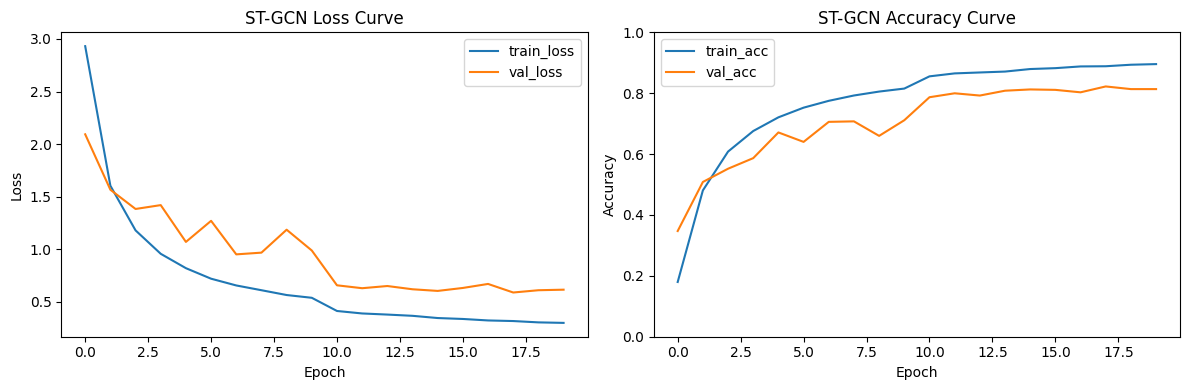

training curves saved to: /content/drive/MyDrive/skeleton_project_outputs/stgcn/training_curves_stgcn.png


In [25]:
# Plot training curves and save figure
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ST-GCN Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], label="train_acc")
plt.plot(history["val_acc"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ST-GCN Accuracy Curve")
plt.ylim(0.0, 1.0)
plt.legend()

plt.tight_layout()
curve_path = os.path.join(SAVE_DIR, "training_curves_stgcn.png")
plt.savefig(curve_path, dpi=300, bbox_inches="tight")
plt.show()
print("training curves saved to:", curve_path)


In [26]:
# Cell 13: Load best model and inspect predictions

# NTU RGB+D 60 class names used in exported confusion CSVs
ntu60_class_names = [
    "drink water",
    "eat meal",
    "brush teeth",
    "brush hair",
    "drop",
    "pick up",
    "throw",
    "sit down",
    "stand up",
    "clapping",
    "reading",
    "writing",
    "tear up paper",
    "put on jacket",
    "take off jacket",
    "put on a shoe",
    "take off a shoe",
    "put on glasses",
    "take off glasses",
    "put on a hat/cap",
    "take off a hat/cap",
    "cheer up",
    "hand waving",
    "kicking something",
    "reach into pocket",
    "hopping",
    "jump up",
    "phone call",
    "play with phone/tablet",
    "type on a keyboard",
    "point to something",
    "taking a selfie",
    "check time (from watch)",
    "rub two hands",
    "nod head/bow",
    "shake head",
    "wipe face",
    "salute",
    "put palms together",
    "cross hands in front",
    "sneeze/cough",
    "staggering",
    "falling down",
    "headache",
    "chest pain",
    "back pain",
    "neck pain",
    "nausea/vomiting",
    "fan self",
    "punch/slap",
    "kicking",
    "pushing",
    "pat on back",
    "point finger",
    "hugging",
    "giving object",
    "touch pocket",
    "shaking hands",
    "walking towards",
    "walking apart",
]

model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

x_batch, y_batch = next(iter(val_loader))
x_batch = x_batch.to(device)
y_batch = y_batch.to(device)

with torch.no_grad():
    logits = model(x_batch)
    preds = logits.argmax(dim=1)

print("ground truth:", y_batch[:20].cpu().numpy())
print("predictions :", preds[:20].cpu().numpy())


ground truth: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
predictions : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18  3]


In [27]:
# Confusion analysis setup: collect validation predictions once
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
class_names = globals().get("ntu60_class_names", [str(i) for i in range(cm.shape[0])])
print("num validation samples:", len(all_labels))
print("confusion matrix shape:", cm.shape)


num validation samples: 16487
confusion matrix shape: (60, 60)


raw confusion matrix saved to: /content/drive/MyDrive/skeleton_project_outputs/stgcn/confusion_matrix_stgcn_raw.png


<Figure size 1600x1400 with 0 Axes>

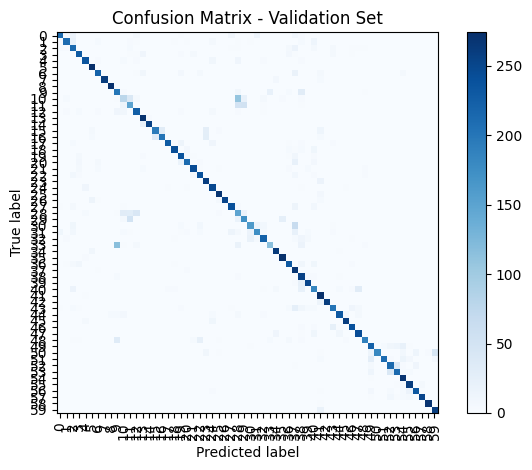

In [28]:
# Save raw confusion matrix
plt.figure(figsize=(16, 14))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(
    cmap="Blues",
    values_format=None,
    xticks_rotation=90,
    colorbar=True
)

# Hide numbers inside cells to avoid overlap
for text in disp.text_.ravel():
    text.set_visible(False)

plt.title("Confusion Matrix - Validation Set")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()

cm_raw_path = os.path.join(SAVE_DIR, "confusion_matrix_stgcn_raw.png")
plt.savefig(cm_raw_path, dpi=300, bbox_inches="tight")
print("raw confusion matrix saved to:", cm_raw_path)
plt.show()


normalized confusion matrix saved to: /content/drive/MyDrive/skeleton_project_outputs/stgcn/confusion_matrix_stgcn_normalized.png


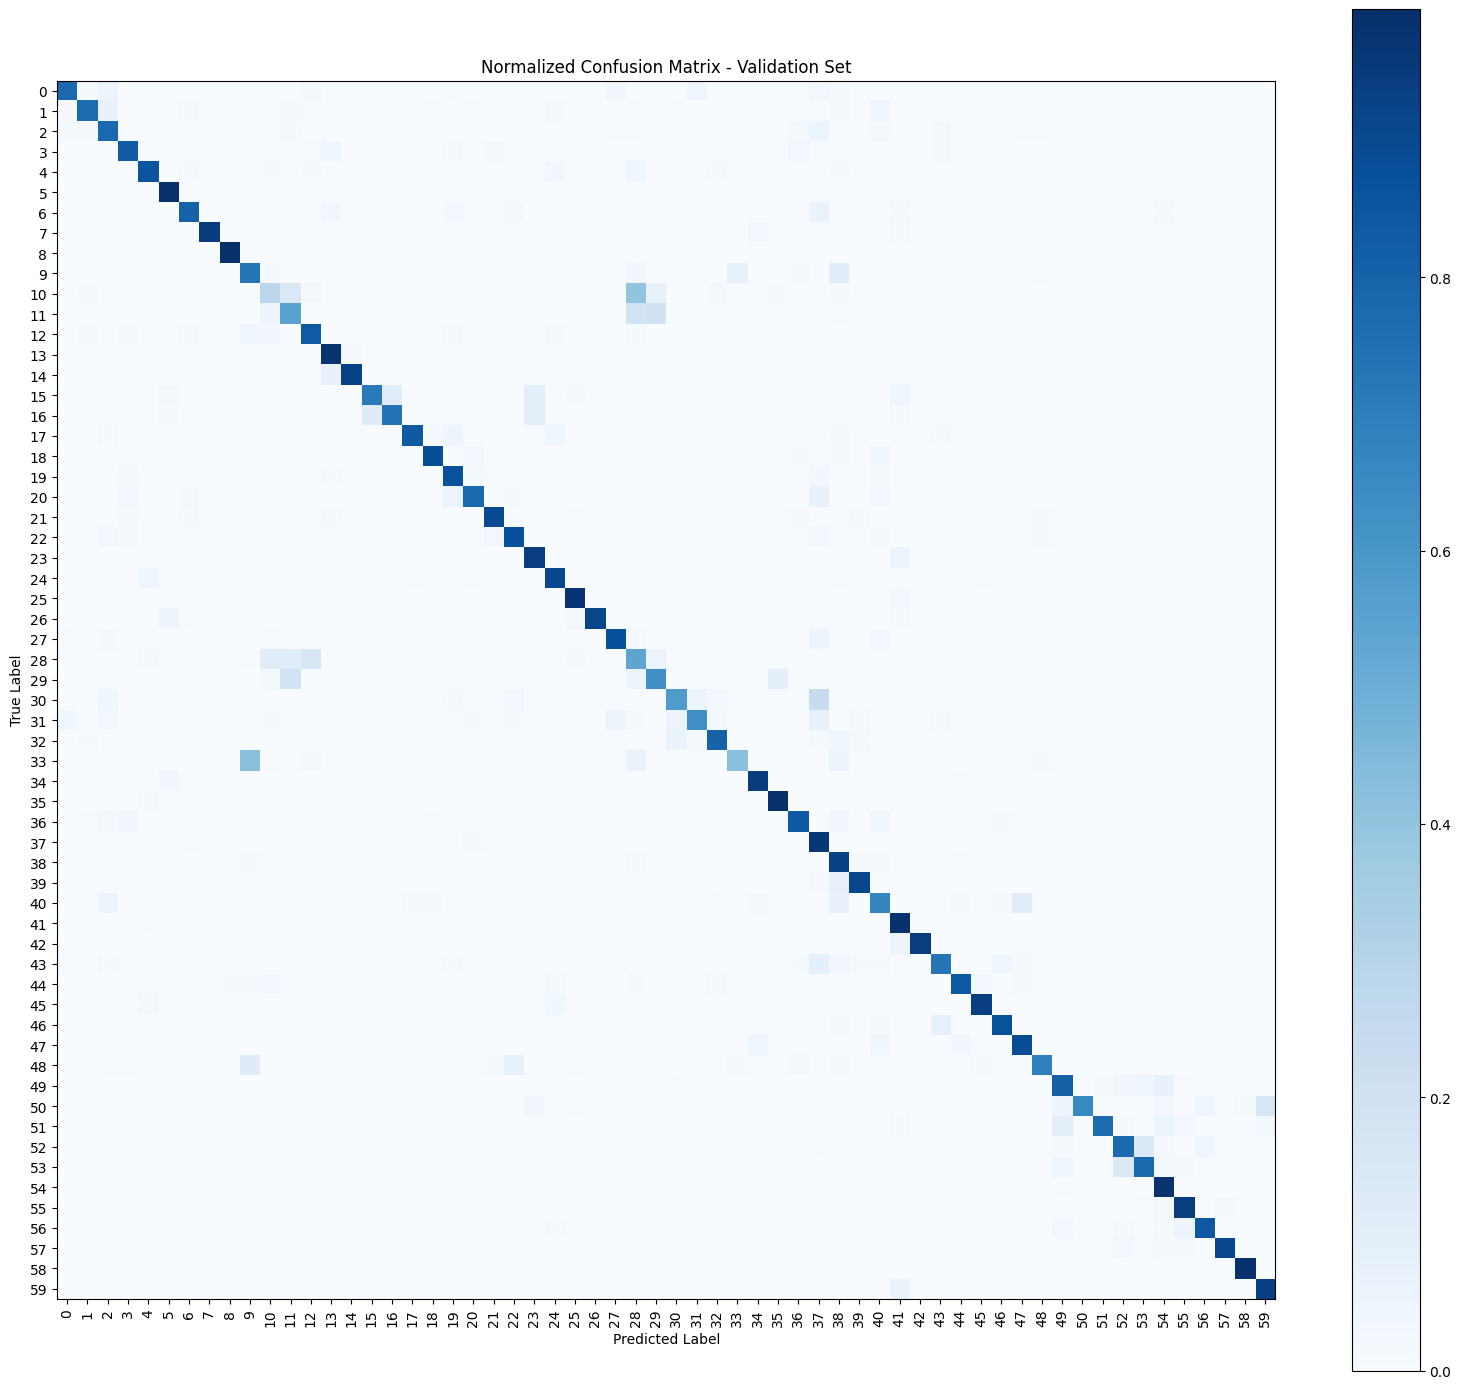

In [29]:
# Save normalized confusion matrix
cm_norm = confusion_matrix(all_labels, all_preds, normalize="true")
fig, ax = plt.subplots(figsize=(16, 14))
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm)
disp_norm.plot(
    ax=ax,
    cmap="Blues",
    values_format=".2f",
    xticks_rotation=90,
    colorbar=True,
)

# Hide dense cell labels; the heatmap is easier to read for 60 classes.
for text in disp_norm.text_.ravel():
    text.set_visible(False)

plt.title("Normalized Confusion Matrix - Validation Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
cm_norm_path = os.path.join(SAVE_DIR, "confusion_matrix_stgcn_normalized.png")
plt.savefig(cm_norm_path, dpi=300, bbox_inches="tight")
print("normalized confusion matrix saved to:", cm_norm_path)
plt.show()


In [30]:
# Save top confused pairs by raw count
confusions = []

for true_class in range(cm.shape[0]):
    true_total = cm[true_class].sum()
    for pred_class in range(cm.shape[1]):
        count = int(cm[true_class, pred_class])
        if true_class != pred_class and count > 0:
            rate = count / true_total if true_total > 0 else 0.0
            confusions.append({
                "True class": true_class,
                "True name": class_names[true_class] if true_class < len(class_names) else str(true_class),
                "Predicted class": pred_class,
                "Predicted name": class_names[pred_class] if pred_class < len(class_names) else str(pred_class),
                "Count": count,
                "Rate within true class": rate,
            })

confusion_df = pd.DataFrame(confusions)
top_confusions = confusion_df.sort_values(by="Count", ascending=False).head(10)
print(top_confusions)

top_confusions_path = os.path.join(SAVE_DIR, "top_confusions_stgcn.csv")
top_confusions.to_csv(top_confusions_path, index=False)
print("top confusions saved to:", top_confusions_path)


     True class               True name  Predicted class  \
288          33           rub two hands                9   
102          10                 reading               28   
257          30      point to something               37   
112          11                 writing               29   
243          29      type on a keyboard               11   
111          11                 writing               28   
428          50                 kicking               59   
237          28  play with phone/tablet               12   
451          53            point finger               52   
98           10                 reading               11   

             Predicted name  Count  Rate within true class  
288                clapping    116                0.420290  
102  play with phone/tablet    109                0.399267  
257                  salute     65                0.235507  
112      type on a keyboard     53                0.194853  
243                 writing     51

In [31]:
# Save top confused pairs by rate within true class
if "confusion_df" not in globals():
    confusions = []
    for true_class in range(cm.shape[0]):
        true_total = cm[true_class].sum()
        for pred_class in range(cm.shape[1]):
            count = int(cm[true_class, pred_class])
            if true_class != pred_class and count > 0:
                rate = count / true_total if true_total > 0 else 0.0
                confusions.append({
                    "True class": true_class,
                    "True name": class_names[true_class] if true_class < len(class_names) else str(true_class),
                    "Predicted class": pred_class,
                    "Predicted name": class_names[pred_class] if pred_class < len(class_names) else str(pred_class),
                    "Count": count,
                    "Rate within true class": rate,
                })
    confusion_df = pd.DataFrame(confusions)

top_confusions_by_rate = confusion_df.sort_values(by="Rate within true class", ascending=False).head(10)
print(top_confusions_by_rate)

top_confusions_rate_path = os.path.join(SAVE_DIR, "top_confusions_stgcn_by_rate.csv")
top_confusions_by_rate.to_csv(top_confusions_rate_path, index=False)
print("top confusions by rate saved to:", top_confusions_rate_path)


     True class               True name  Predicted class  \
288          33           rub two hands                9   
102          10                 reading               28   
257          30      point to something               37   
112          11                 writing               29   
243          29      type on a keyboard               11   
111          11                 writing               28   
428          50                 kicking               59   
237          28  play with phone/tablet               12   
98           10                 reading               11   
451          53            point finger               52   

             Predicted name  Count  Rate within true class  
288                clapping    116                0.420290  
102  play with phone/tablet    109                0.399267  
257                  salute     65                0.235507  
112      type on a keyboard     53                0.194853  
243                 writing     51

In [32]:
# Save classification report
report = classification_report(all_labels, all_preds, digits=4)
print(report)

report_path = os.path.join(SAVE_DIR, "classification_report_stgcn.txt")
with open(report_path, "w") as f:
    f.write(report)
print("classification report saved to:", report_path)


              precision    recall  f1-score   support

           0     0.8945    0.7737    0.8297       274
           1     0.8792    0.7673    0.8194       275
           2     0.6741    0.7802    0.7233       273
           3     0.8382    0.8352    0.8367       273
           4     0.8835    0.8545    0.8688       275
           5     0.8867    0.9964    0.9384       275
           6     0.8947    0.8036    0.8467       275
           7     1.0000    0.9524    0.9756       273
           8     0.9819    0.9927    0.9872       273
           9     0.5305    0.7326    0.6154       273
          10     0.4780    0.2784    0.3519       273
          11     0.5284    0.5478    0.5379       272
          12     0.7627    0.8303    0.7951       271
          13     0.8464    0.9818    0.9091       275
          14     0.9884    0.9239    0.9551       276
          15     0.8546    0.7106    0.7760       273
          16     0.8632    0.7372    0.7953       274
          17     0.9745    